In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [68]:
# Load the dataset 
data = pd.read_csv("Cleaned_Data.csv")

In [5]:
data.head()

,date,Region,County,market,latitude,longitude,category,commodity,unit,price
0,1/15/2006,Coast,MOMBASA,Mombasa,-4.05,39.67,cereals and tubers,Maize,KG,16.13
1,1/15/2006,Coast,MOMBASA,Mombasa,-4.05,39.67,cereals and tubers,Maize (white),90 KG,1480.00
2,1/15/2006,Coast,MOMBASA,Mombasa,-4.05,39.67,pulses and nuts,Beans,KG,33.63
3,1/15/2006,Coast,MOMBASA,Mombasa,-4.05,39.67,pulses and nuts,Beans (dry),90 KG,3246.00
4,1/15/2006,Eastern,KITUI,Kitui,-1.37,38.02,cereals and tubers,Maize (white),KG,17.00


In [6]:
data.tail()

,date,Region,County,market,latitude,longitude,category,commodity,unit,price
18551,3/15/2026,North Eastern,GARISSA,IFO (Daadab),0.11,40.32,"meat, fish and eggs",Meat (goat),KG,825.00
18552,3/15/2026,North Eastern,GARISSA,IFO (Daadab),0.11,40.32,miscellaneous food,Salt,200 G,15.00
18553,3/15/2026,North Eastern,GARISSA,IFO (Daadab),0.11,40.32,miscellaneous food,Sugar,KG,120.00
18554,3/15/2026,North Eastern,GARISSA,IFO (Daadab),0.11,40.32,oil and fats,Oil (vegetable),L,247.78
18555,3/15/2026,North Eastern,GARISSA,IFO (Daadab),0.11,40.32,vegetables and fruits,Bananas,Unit,10.00


In [69]:
# convert the date column to python datetime objects
data["date"] = pd.to_datetime(data["date"],errors="coerce")
data.head()

,date,Region,County,market,latitude,longitude,category,commodity,unit,price
0,2006-01-15,Coast,MOMBASA,Mombasa,-4.05,39.67,cereals and tubers,Maize,KG,16.13
1,2006-01-15,Coast,MOMBASA,Mombasa,-4.05,39.67,cereals and tubers,Maize (white),90 KG,1480.00
2,2006-01-15,Coast,MOMBASA,Mombasa,-4.05,39.67,pulses and nuts,Beans,KG,33.63
3,2006-01-15,Coast,MOMBASA,Mombasa,-4.05,39.67,pulses and nuts,Beans (dry),90 KG,3246.00
4,2006-01-15,Eastern,KITUI,Kitui,-1.37,38.02,cereals and tubers,Maize (white),KG,17.00


In [70]:
# set the date as the Index, ARIMA needs a time index to understand the sequence 
data.set_index("date",inplace=True)
data.head()


,Region,County,market,latitude,longitude,category,commodity,unit,price
date,,,,,,,,,
2006-01-15,Coast,MOMBASA,Mombasa,-4.05,39.67,cereals and tubers,Maize,KG,16.13
2006-01-15,Coast,MOMBASA,Mombasa,-4.05,39.67,cereals and tubers,Maize (white),90 KG,1480.00
2006-01-15,Coast,MOMBASA,Mombasa,-4.05,39.67,pulses and nuts,Beans,KG,33.63
2006-01-15,Coast,MOMBASA,Mombasa,-4.05,39.67,pulses and nuts,Beans (dry),90 KG,3246.00
2006-01-15,Eastern,KITUI,Kitui,-1.37,38.02,cereals and tubers,Maize (white),KG,17.00


<Axes: xlabel='date'>

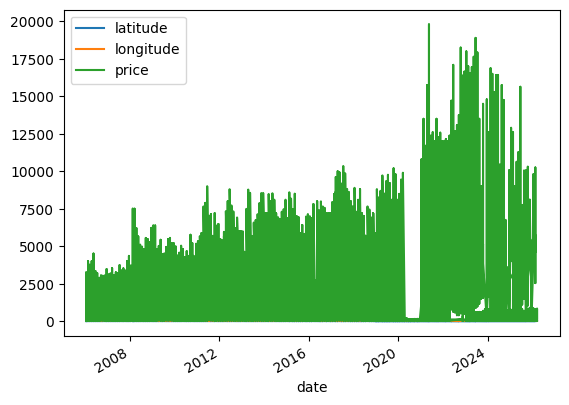

In [11]:
# Visualize the data
data.plot()

In [ ]:
# Testing if the data is stationary
from statsmodels.tsa.stattools import adfuller


In [71]:
test_result=adfuller(data["price"])

In [16]:
#H0: it's not stationary
#H1: It is atationary
def adfuller_test(price):
    result=adfuller(price)
    labels = ["ADF Test Statistic","p-value","#Lags Used","Number of Observations Used"]
    for value,label in zip(result,labels):
        print(label+":"+str(value))
        if results[1] <= 0.05:
            print("strong evidence against the null hypothesis,reject the null hypothesis")
        else:
            print("Weak evidence against the null hypothesis,do not reject the null hypothesis")


In [19]:
results = adfuller(data["price"])
print("results:",results)

results: (np.float64(-5.005675342234093), np.float64(2.162627870160857e-05), 44, 18511, {'1%': np.float64(-3.430703314626113), '5%': np.float64(-2.8616961519553628), '10%': np.float64(-2.56685311553928)}, np.float64(332993.2676637304))


In [72]:
# making the data stationary
# Differencing,this removes trends like inflation so that the model can only see the patterns
# Subtract yesterdays price from current price
data["price first difference"] = data["price"] - data["price"].shift(1)
data["price"].shift(1)

date
2006-01-15        NaN
2006-01-15      16.13
2006-01-15    1480.00
2006-01-15      33.63
2006-01-15    3246.00
               ...   
2026-03-15     100.00
2026-03-15     825.00
2026-03-15      15.00
2026-03-15     120.00
2026-03-15     247.78
Name: price, Length: 18556, dtype: float64

In [24]:
adfuller(data["price first difference"].dropna())

(np.float64(-29.35324846256511),
 0.0,
 45,
 18509,
 {'1%': np.float64(-3.4307033528090125),
  '5%': np.float64(-2.8616961688297833),
  '10%': np.float64(-2.5668531245212605)},
 np.float64(332998.06510193116))

<Axes: xlabel='date'>

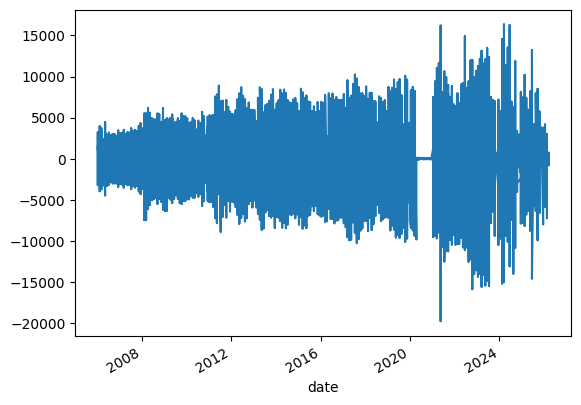

In [25]:
data["price first difference"].plot()

In [31]:
import statsmodels.api as sm

In [73]:
# Auto Regressive Model
# ACF and PACF Plots help find the p,q,d parameters needed
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

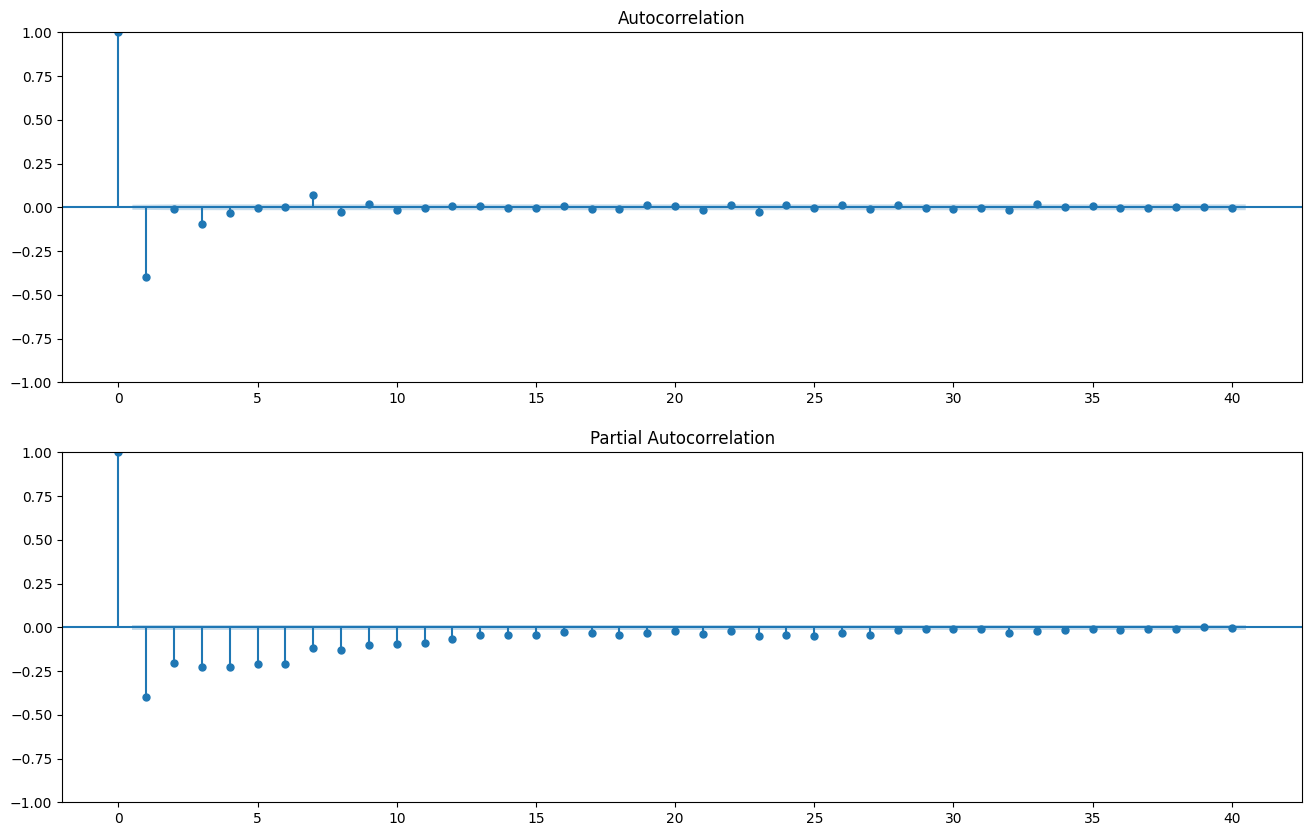

In [38]:
fig= plt.figure(figsize=(16,10))
ax1= fig.add_subplot(211)
fig= sm.graphics.tsa.plot_acf(data["price first difference"].iloc[13:],lags=40,ax=ax1)
ax2= fig.add_subplot(212)
fig=sm.graphics.tsa.plot_pacf(data["price first difference"].iloc[13:],lags=40,ax=ax2)

In [ ]:
# P=0,d=1,q=0
from statsmodels.tsa.arima_model import ARIMA

In [67]:
model=sm.tsa.statespace.SARIMAX(data["price"],order=(0,1,0),price_order=(0,1,0.12))
data['shifted_price'] = data['price'].shift(1) 


c:\Users\PC\Python-Capstone-Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Python-Capstone-Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Python-Capstone-Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\PC\Python-Capstone-Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting

In [57]:
from pandas.tseries.offsets import DateOffset
future_dates=[data.index[-1]+DateOffset(year=x)for x in range(0,24)]

In [59]:
future_dataset_data=pd.DataFrame(index=future_dates[1:],columns=data.columns)

In [60]:
future_dataset_data.tail()

,Region,County,market,latitude,longitude,category,commodity,unit,price,price first difference,shifted_price
19-03-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20-03-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21-03-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22-03-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23-03-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
len(data)

18556

In [61]:
future_data=pd.concat([data,future_dataset_data])

In [76]:
model_results = model.fit()

In [78]:
# Predict 15 steps into the future (the size of your future_dates)
future_data = model_results.forecast(steps=15)

# 2. Add those predictions to your 'future_data' table
future_dataset_data["forecast"]=future_data.values

# 3. THE RESTOCK SYSTEM LOGIC
# Compare the price today vs the price 3 months from now
current_p = data["price"].iloc[-1]
future_p = future_dataset_data["forecast"].iloc[3] # 3 months out

price_change_pct = (future_p - current_p) / current_p

print(f"--- RESTOCK ANALYSIS ---")
print(f"Current Price: {current_p:.2f}")
print(f"Predicted Price (3m): {future_p:.2f}")

if price_change_pct > 0.05:
    print("ALERT: Price is predicted to rise by more than 5%. RESTOCK NOW.")
elif price_change_pct < -0.05:
    print("ADVICE: Price is predicted to drop. Delay restocking to save money.")
else:
    print("STATUS: Price is stable. Maintain standard inventory.")

c:\Users\PC\Python-Capstone-Project\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


ValueError: Length of values (15) does not match length of index (23)